#Project: Customer Lifetime Value Prediction Model

In [1]:
import pandas as pd
import numpy as np

Data Cleaning

In [3]:
# Load the CSV File
df = pd.read_csv('/content/Online Retail Data Set.csv', encoding='latin-1')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [5]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [6]:
# Check for missing values
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [7]:
df_clean = df.dropna(subset=['CustomerID'])

In [9]:
df_clean.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [11]:
# Convert to date-time format
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'], format='%d-%m-%Y %H:%M')

<ipython-input-11-493329742aa8>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'], format='%d-%m-%Y %H:%M')


In [12]:
# Create TotalPrice Column
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

<ipython-input-12-3c31972674b1>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']


In [13]:
df_clean.info()
df_clean.head()

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    406829 non-null  object        
 1   StockCode    406829 non-null  object        
 2   Description  406829 non-null  object        
 3   Quantity     406829 non-null  int64         
 4   InvoiceDate  406829 non-null  datetime64[ns]
 5   UnitPrice    406829 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      406829 non-null  object        
 8   TotalPrice   406829 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 31.0+ MB


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [14]:
#Save clean data
df.to_csv("cleaned_data_project.csv", index=False)

In [15]:
#Download cleaned csv file
from google.colab import files
files.download('cleaned_data_project.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Feature Engineering

In [16]:
# Reference date = last transaction date in dataset
reference_date = df_clean['InvoiceDate'].max()

In [17]:
# Group by customer and calculate features
customer_metrics = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                    # Frequency
    'TotalPrice': 'sum'                                        # Monetary
}).reset_index()

In [18]:
# Rename columns
customer_metrics.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

In [19]:
# Calculate AOV (Average Order Value)
customer_metrics['AOV'] = customer_metrics['Monetary'] / customer_metrics['Frequency']

In [20]:
# Preview
customer_metrics.head()

,CustomerID,Recency,Frequency,Monetary,AOV
0,12346.0,325,2,0.00,0.000000
1,12347.0,1,7,4310.00,615.714286
2,12348.0,74,4,1797.24,449.310000
3,12349.0,18,1,1757.55,1757.550000
4,12350.0,309,1,334.40,334.400000


In [21]:
# Export to CSV
customer_metrics.to_csv('customer_metrics.csv', index=False)

In [22]:
# Download the CSV to your system
from google.colab import files
files.download('customer_metrics.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Visualizations

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

Distribution of Recency, Frequency, Monetary

In [25]:
# Set style
sns.set(style="whitegrid")

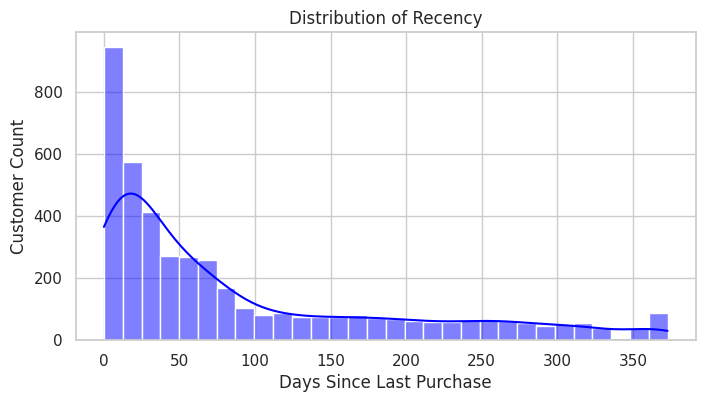

In [26]:
# Recency distribution
plt.figure(figsize=(8, 4))
sns.histplot(customer_metrics['Recency'], kde=True, bins=30, color='blue')
plt.title('Distribution of Recency')
plt.xlabel('Days Since Last Purchase')
plt.ylabel('Customer Count')
plt.show()

In [47]:
plt.savefig('Recency distribution.png')

<Figure size 640x480 with 0 Axes>

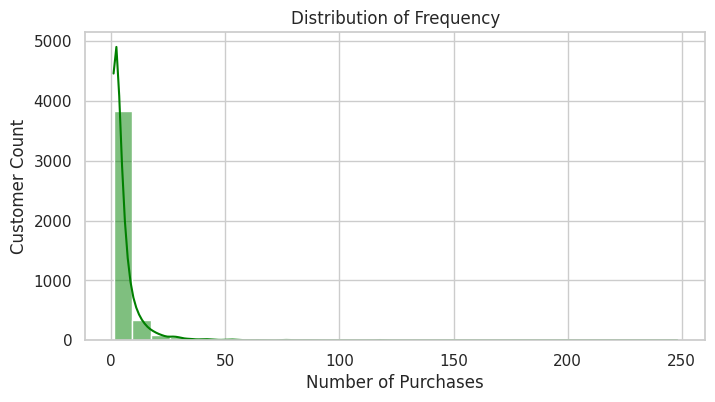

In [27]:
# Frequency
plt.figure(figsize=(8, 4))
sns.histplot(customer_metrics['Frequency'], kde=True, bins=30, color='green')
plt.title('Distribution of Frequency')
plt.xlabel('Number of Purchases')
plt.ylabel('Customer Count')
plt.show()

In [48]:
plt.savefig('Distribution of Frequency.png')

<Figure size 640x480 with 0 Axes>

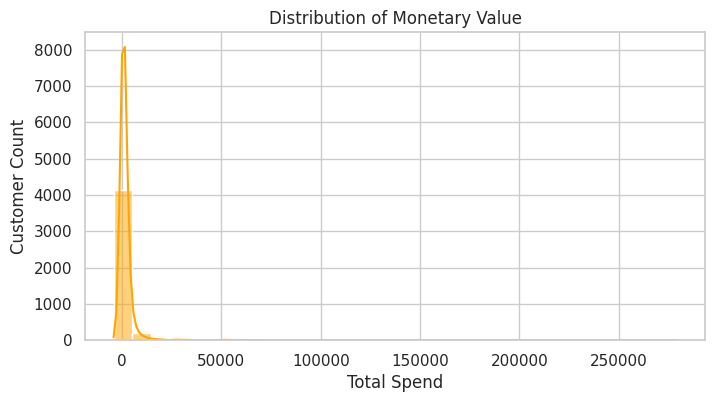

In [28]:
# Monetary
plt.figure(figsize=(8, 4))
sns.histplot(customer_metrics['Monetary'], kde=True, bins=30, color='orange')
plt.title('Distribution of Monetary Value')
plt.xlabel('Total Spend')
plt.ylabel('Customer Count')
plt.show()

In [49]:
plt.savefig('Distribution of Monetary Value.png')

<Figure size 640x480 with 0 Axes>

Scatter Plot: Frequency vs Monetary

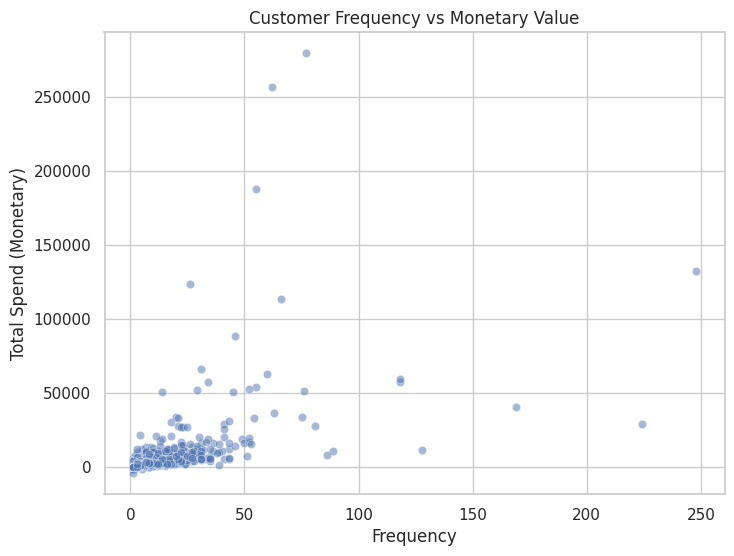

In [29]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Frequency', y='Monetary', data=customer_metrics, alpha=0.5)
plt.title('Customer Frequency vs Monetary Value')
plt.xlabel('Frequency')
plt.ylabel('Total Spend (Monetary)')
plt.show()

In [50]:
plt.savefig('Frequency vs Monetary.png')

<Figure size 640x480 with 0 Axes>

#Model Building

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb

Define Features and Target

In [32]:
# Features and Target
X = customer_metrics[['Recency', 'Frequency', 'AOV']]
y = customer_metrics['Monetary']  # Treating Monetary as current LTV

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:
# Training the model
model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [36]:
# Predict and Evaluate the Model
# Predictions
y_pred = model.predict(X_test)

# Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE: 318.75
RMSE: 4828.87


In [37]:
# Adding Predicted LTV to DataFrame
customer_metrics['PredictedLTV'] = model.predict(X)

In [38]:
# Creating segments based on predicted LTV
customer_metrics['Segment'] = pd.qcut(customer_metrics['PredictedLTV'], q=3, labels=['Low', 'Medium', 'High'])
customer_metrics.head()

,CustomerID,Recency,Frequency,Monetary,AOV,PredictedLTV,Segment
0,12346.0,325,2,0.00,0.000000,14.091276,Low
1,12347.0,1,7,4310.00,615.714286,4282.941406,High
2,12348.0,74,4,1797.24,449.310000,1785.101562,High
3,12349.0,18,1,1757.55,1757.550000,1766.970825,High
4,12350.0,309,1,334.40,334.400000,340.605682,Low


In [39]:
# Save final output
customer_metrics.to_csv('final_ltv_predictions.csv', index=False)

In [40]:
# Download it
from google.colab import files
files.download('final_ltv_predictions.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#Visualizations for Predicted LTV and Segments

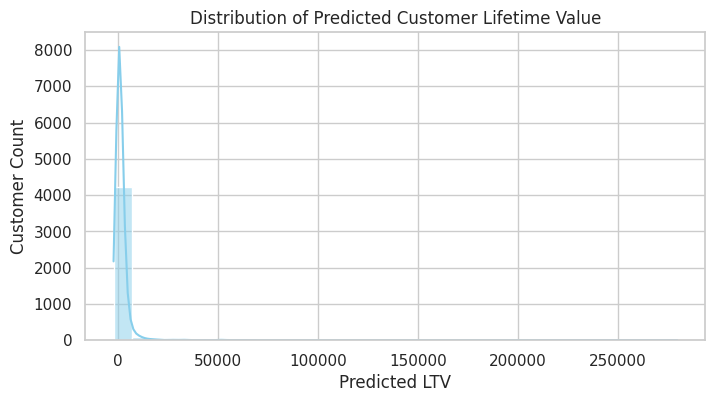

In [43]:
# Distribution of Predicted LTV
plt.figure(figsize=(8, 4))
sns.histplot(customer_metrics['PredictedLTV'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Predicted Customer Lifetime Value')
plt.xlabel('Predicted LTV')
plt.ylabel('Customer Count')
plt.show()

In [51]:
plt.savefig('Distribution of Predicted LTV.png')

<Figure size 640x480 with 0 Axes>

<ipython-input-44-e5eeb086994e>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Segment', y='PredictedLTV', data=customer_metrics, palette='Set2')


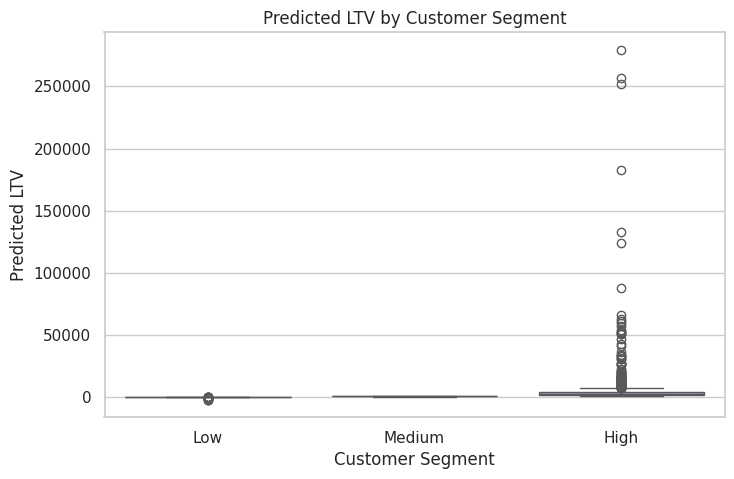

In [44]:
# LTV by Segment
plt.figure(figsize=(8, 5))
sns.boxplot(x='Segment', y='PredictedLTV', data=customer_metrics, palette='Set2')
plt.title('Predicted LTV by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Predicted LTV')
plt.show()

In [52]:
plt.savefig('LTV by Segment.png')

<Figure size 640x480 with 0 Axes>

<ipython-input-45-95e6659b8370>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Segment', data=customer_metrics, palette='Pastel1')


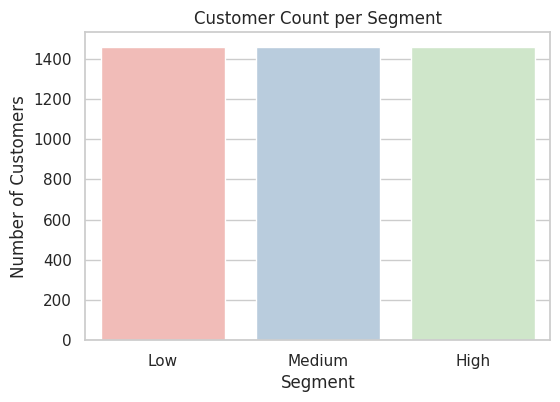

In [45]:
# Segment Counts
plt.figure(figsize=(6, 4))
sns.countplot(x='Segment', data=customer_metrics, palette='Pastel1')
plt.title('Customer Count per Segment')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.show()

In [53]:
plt.savefig('Segment Counts.png')

<Figure size 640x480 with 0 Axes>

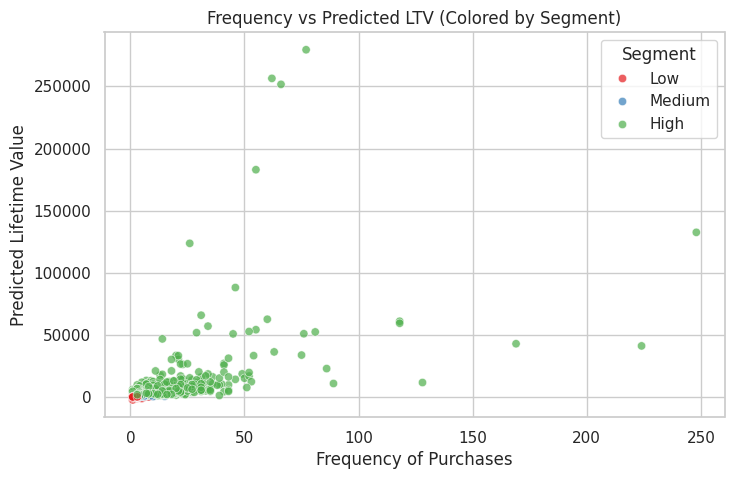

In [46]:
#Scatter Plot: Frequency vs Predicted LTV
plt.figure(figsize=(8, 5))
sns.scatterplot(data=customer_metrics, x='Frequency', y='PredictedLTV', hue='Segment', palette='Set1', alpha=0.7)
plt.title('Frequency vs Predicted LTV (Colored by Segment)')
plt.xlabel('Frequency of Purchases')
plt.ylabel('Predicted Lifetime Value')
plt.legend(title='Segment')
plt.show()

In [54]:
plt.savefig('Frequency vs Predicted LTV.png')

<Figure size 640x480 with 0 Axes>

In [55]:
import zipfile
import os

In [56]:
# List all PNGs
image_files = [
    'Recency distribution.png',
    'Distribution of Frequency.png',
    'Distribution of Monetary Value.png',
    'Frequency vs Monetary.png',
    'Distribution of Predicted LTV.png',
    'LTV by Segment.png',
    'Segment Counts.png',
    'Frequency vs Predicted LTV.png'
]

In [57]:
# Create a zip file
with zipfile.ZipFile('Project_graphs.zip', 'w') as zipf:
    for file in image_files:
        zipf.write(file)

In [58]:
from google.colab import files
files.download('Project_graphs.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>